In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import json

In [8]:
DATA_ROOT = "/workspace/yb-soc-two-body-loss/data/temp0905"

In [9]:
def query_condition(name):
    if "trend" not in name:
        return False
    timestamp = name[-8:]
    if not str.isdigit(timestamp):
        return False
    return "0904" in timestamp

for name in os.listdir(DATA_ROOT):
    if query_condition(name):
        print(name)

trend_lindblad_13_7_09040730
trend_lindblad_13_6_09041841
trend_lindblad_13_6_09041912
trend_lindblad_13_6_09041944
trend_lindblad_13_6_09042016
trend_lindblad_13_6_09042047
trend_lindblad_13_6_09042118


In [10]:
DATA_SUBDIR_LIST = [
    "trend_lindblad_13_6_09041841",
    "trend_lindblad_13_6_09041912",
    "trend_lindblad_13_6_09041944",
    "trend_lindblad_13_6_09042016",
    "trend_lindblad_13_6_09042047",
    "trend_lindblad_13_6_09042118",
]
DATA_SUBDIR_FULL = [
    os.path.join(DATA_ROOT, name) for name in DATA_SUBDIR_LIST
]

In [11]:
def load_params(data_dir):
    data_path = os.path.join(data_dir, "data/parameters.json")
    with open(data_path, 'r') as f:
        params = json.load(f)
    return params

def load_nparray(data_dir, file_name):
    data_path = os.path.join(data_dir, "data", file_name)
    with open(data_path, 'rb') as f:
        nparr = np.load(f)
    return nparr

def load_times(data_dir):
    return load_nparray(data_dir, "t.npy")

def load_full_momentum_nums(data_dir):
    up_nums = load_nparray(data_dir, "full_up_nums_momentum.npy")
    down_nums = load_nparray(data_dir, "full_down_nums_momentum.npy")
    return up_nums, down_nums

In [12]:
err = 0
params = []
for idx, data_dir in enumerate(DATA_SUBDIR_FULL):
    params.append(load_params(data_dir))

In [13]:
def merge_params(params_list):
    if not params_list:
        return {}, []

    merged_keys = set()

    def _recursive_merge(current_params_list, path_prefix=""):
        if not current_params_list:
            return {}

        all_keys = set().union(*(d.keys() for d in current_params_list))
        merged_dict = {}

        for key in all_keys:
            values = [d.get(key) for d in current_params_list if key in d]
            
            unique_values = []
            for v in values:
                if v not in unique_values:
                    unique_values.append(v)
            
            full_key_path = f"{path_prefix}{key}"

            if len(unique_values) == 1:
                merged_dict[key] = unique_values[0]
            else:
                if all(isinstance(v, dict) for v in unique_values):
                    merged_dict[key] = _recursive_merge(unique_values, path_prefix=f"{full_key_path}.")
                else:
                    merged_keys.add(full_key_path)
                    merged_dict[key] = unique_values
        
        return merged_dict

    final_merged_dict = _recursive_merge(params_list)

    return final_merged_dict, sorted(list(merged_keys))

In [14]:
merged_params, merged = merge_params(params)
print(merged)
pointer = merged_params
for key in merged[0].split('.'):
    pointer = pointer[key]
print(f"{key}: {pointer}")
print(json.dumps(merged_params, indent=4))

['pa.gamma']
gamma: [0.1, 0.25, 0.4, 0.7, 1.0, 2.0]
{
    "n_particles": 6,
    "pa": {
        "gamma": [
            0.1,
            0.25,
            0.4,
            0.7,
            1.0,
            2.0
        ],
        "T2": 0.8
    },
    "L": 12.566370614359172,
    "n_momentum_points": 13,
    "k0": 0.5,
    "m_Yb": 1.0,
    "hbar": 1.0,
    "simulation_settings": {
        "t0": 0,
        "t1": 3.0,
        "n_savesteps": 61,
        "step_size": 0.4428697962798937,
        "n_trajectories": 512,
        "batch_size": 64,
        "jumps_per_step": 4,
        "num_batches": 8,
        "total_n_steps": 240,
        "delta_t": 0.11071744906997343,
        "seed": 0
    },
    "soc": {
        "k_r": 1.0,
        "delta": 4.0,
        "omega_R": 3.5
    }
}


In [15]:
err = 0
for idx, data_dir in enumerate(DATA_SUBDIR_FULL):
    ts = load_times(data_dir)
    if idx == 0:
        ts_ref = ts
    else:
        err += np.mean(np.abs(ts - ts_ref))
print('error:', err)

error: 0.0


In [16]:
# System definition
t_r = 0.1129 # ms
E_r = 9.3428e-31 # J
T_r = 6.7669e-2 # μK

In [17]:
ts = ts_ref
ts_ms = ts_ref * t_r
print(f"{len(ts)=}")
print(ts_ms)

len(ts)=61
[0.   0.05 0.1  0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5  0.55 0.6  0.65
 0.7  0.75 0.8  0.85 0.9  0.95 1.   1.05 1.1  1.15 1.2  1.25 1.3  1.35
 1.4  1.45 1.5  1.55 1.6  1.65 1.7  1.75 1.8  1.85 1.9  1.95 2.   2.05
 2.1  2.15 2.2  2.25 2.3  2.35 2.4  2.45 2.5  2.55 2.6  2.65 2.7  2.75
 2.8  2.85 2.9  2.95 3.  ]


In [18]:
t_idx = 20
print(f"{ts_ms[t_idx]} ms")

1.0 ms


In [19]:
gammas = merged_params['pa']['gamma']

In [21]:
gammas

[0.1, 0.25, 0.4, 0.7, 1.0, 2.0]

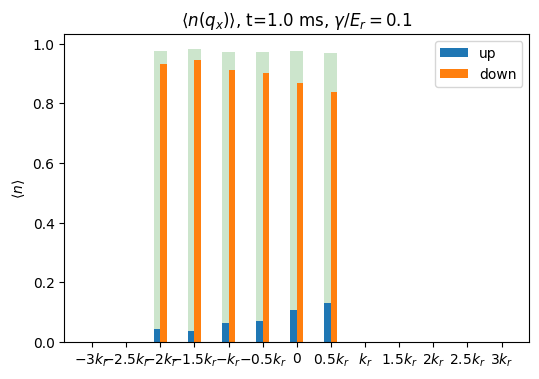

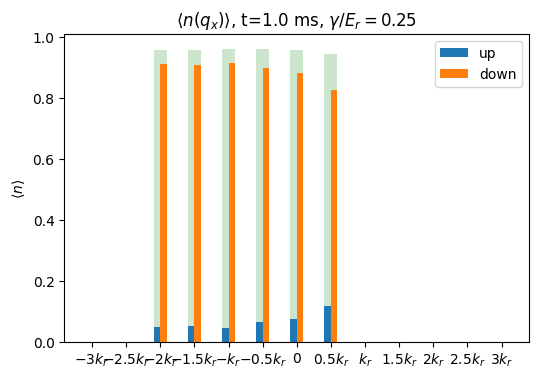

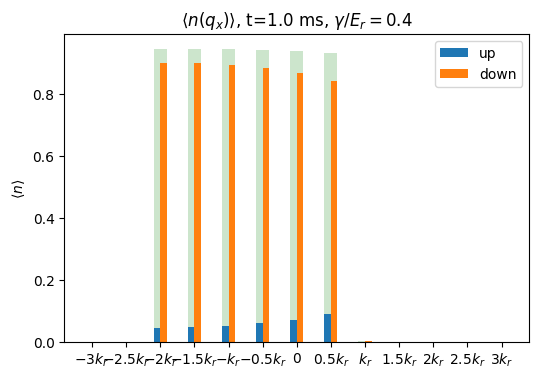

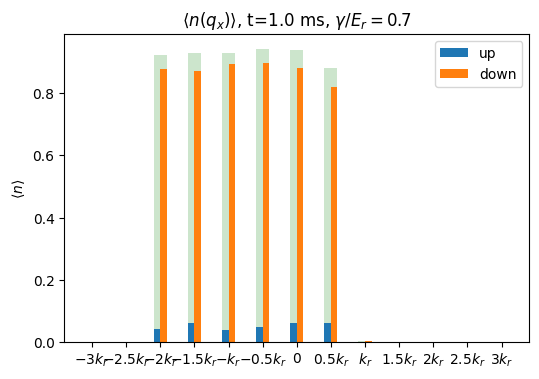

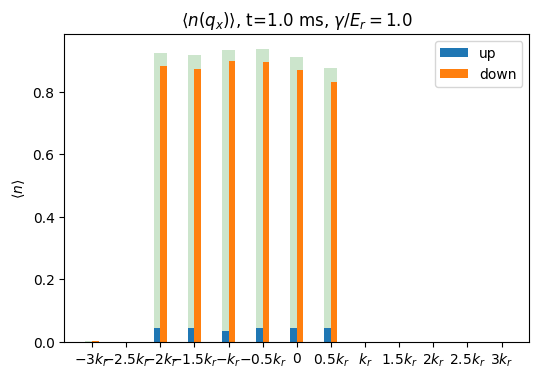

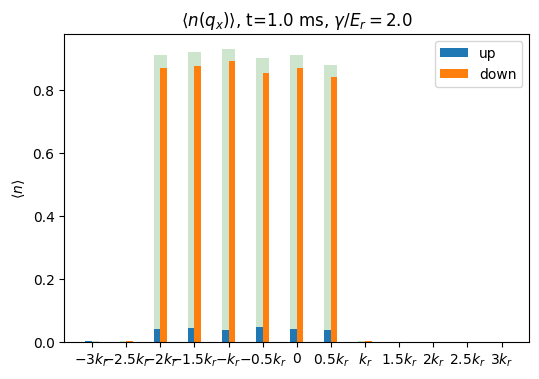

In [ ]:
from quant_mech.plot_utils import (
    plot_numbers,
    generate_k_labels,
    plot_fractions
)



for data_dir in DATA_SUBDIR_FULL:
    # (batch, time, k)
    params = load_params(data_dir)
    k_tick_labels = generate_k_labels(params["n_momentum_points"], params["k0"])
    nums_up, nums_down = load_full_momentum_nums(data_dir)
    
    assert nums_up.shape[0] == nums_down.shape[0]
    n_batch = nums_up.shape[0]
    
    # (batch, k)
    nums_up = nums_up[:, t_idx, :]
    nums_down = nums_down[:, t_idx, :]
    
    
    nums_up_avg = np.mean(nums_up, axis=0)
    nums_up_error = np.std(nums_up, axis=0) / np.sqrt(n_batch)
    nums_down_avg = np.mean(nums_down, axis=0)
    nums_down_error = np.std(nums_down, axis=0) / np.sqrt(n_batch)
    
    gamma = params["pa"]["gamma"]
    
    plot_numbers(
        nums_up_avg,
        nums_down_avg,
        tick_labels=k_tick_labels, 
        ylim=(0, 1.1),
        title=f"$\\langle n(q_x) \\rangle$, t={ts_ms[t_idx]} ms, $\\gamma/E_r=${gamma}",
    )
    